# Shor 9-Qubit QEC — IBM Hardware Comparison

## Phase 5: Run the Shor circuit on real IBM hardware and compare against:
### 1. AerSimulator (ideal, no noise)
### 2. AerSimulator + IBM device calibration noise model (NoiseModel.from_backend)
### 3. Real IBM hardware

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from qiskit.quantum_info import state_fidelity
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService

from shor_code_utils import *
import Utilities as utils
from qiskit.compiler import transpile
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import ClassicalRegister


load_dotenv()
IBM_TOKEN = os.getenv("IBM_TOKEN")

### Create baseline by running with no noise and Aersimulator, fidelity should be 1. 
### Initial state is |+> state
### keeping it |+> so we get a definite starting state

In [11]:
# first setup circuit and run so we have a baseline on sim

alpha = beta = 1/np.sqrt(2)
inital_state, corrected_state = run(alpha, beta, show_circuit=False, shots=1)
fidelity = state_fidelity(inital_state, corrected_state)
print(f"Ideal fidelity (no noise): {fidelity:.4f}")

Ideal fidelity (no noise): 1.0000


## Noisy AerSimulator using noise from Real Hardware (below cell)

### The noisy sim uses IBM's calibration data but makes simplifying assumptions:

`NoiseModel.from_backend(backend)` pulls IBM QC's calibration data — but it makes simplifying assumptions:

| Assumption | Reality |
|-----------|---------|
| Gate errors are **independent** | Qubits disturb each other (crosstalk) |
| Noise is **static** | Calibration drifts between cycles |
| Parallel gates don't interfere | They do — heavy-hex topology has coupling |
| No leakage beyond \|0⟩, \|1⟩ | Qubits can leak to \|2⟩ state |
| Errors have **no memory** | Real noise is non-Markovian |

So:
- **Noisy sim** → what hardware *should* do if IBM's model were perfect
- **Real hardware** → what actually happens with all the messy physics

The gap between them is the result. If they're close, IBM's model is a good predictor. If hardware is worse, crosstalk and drift dominate.


In [12]:
# Run on real IBM hardware with same initial state |+> to obtain noise models only

service = QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_TOKEN)
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=17)
print(f"Running on: {backend.name}")
print(f"Qubits: {backend.num_qubits}")
print(f"Native gates: {backend.operation_names}")
print(f"Description: {backend.description}")

qc=encode(alpha, beta)
qc = syndrome_x_measurement(qc)
qc = syndrome_z_measurement(qc)

transpiled_qc = transpile(qc, backend=backend, optimization_level=3, seed_transpiler=42)

print(f"Transpiled depth: {transpiled_qc.depth()}")
print(f"CZ gate count: {transpiled_qc.count_ops().get('cz', 0)}")

noise_model = NoiseModel.from_backend(backend)
noisy_backend = AerSimulator(noise_model=noise_model)
props = backend.properties()
cz_errors = [props.gate_error('cz', gate.qubits)
             for gate in props.gates if gate.gate == 'cz']
print(f"Avg CZ error rate: {np.mean(cz_errors)*100:.3f}%")
sx_errors = [props.gate_error('sx', gate.qubits)
             for gate in props.gates if gate.gate == 'sx']
print(f"Avg sx error rate: {np.mean(sx_errors)*100:.3f}%")


n_trials = 50
fidelities_noisy_simulator = []

for _ in range(n_trials):
    inital_state, corrected_state = run(alpha, beta, backend=noisy_backend, show_circuit=False, shots=1)
    fidelities_noisy_simulator.append(state_fidelity(inital_state, corrected_state))

avg_fidelity_noisy_simulator = np.mean(fidelities_noisy_simulator)
print(f"Avg fidelity with noise model: {avg_fidelity_noisy_simulator:.4f}")


qiskit_runtime_service._resolve_cloud_instances:WARNING:2026-04-26 16:59:53,199: Default instance not set. Searching all available instances.


Running on: ibm_fez
Qubits: 156
Native gates: ['x', 'delay', 'if_else', 'sx', 'id', 'rz', 'cz', 'measure', 'reset']
Description: None
Transpiled depth: 238
CZ gate count: 122
Avg CZ error rate: 3.316%
Avg sx error rate: 0.691%
Avg fidelity with noise model: 0.8900


## Real Hardware: Run A vs Run B (below cell)

Two circuits submitted to `ibm_fez` in a single job (same calibration window) so the comparison is fair.

### Run A — baseline (no QEC)
`encode → delay → decode → H(q[0]) → measure q[0]`

The `delay` matches Run B's syndrome+correction wall-clock duration, so both runs see a comparable T1/T2 idle-noise budget. No syndrome ancillas, no correction.

### Run B — with Shor code correction (QEC)
`encode → syndrome_x → syndrome_z → correct_error_dynamic → decode → H(q[0]) → measure q[0]`

Mid-circuit `if_test` correction uses `ibm_fez`'s native `if_else` (dynamic circuits).

### Fidelity proxy
Input is |+⟩, so after a perfect decode + H, q[0] = |0⟩ → **P(measuring 0) = fidelity**.

- `p0_A = counts_A['0'] / shots`
- `p0_B = counts_B['0'] / shots`
- `Δ = p0_B − p0_A`

### Interpretation
- **Δ > 0** → QEC helped: corrections recovered more errors than the syndrome circuit introduced.
- **Δ ≤ 0** → QEC hurt: 122 CZ-gate syndrome circuit (~3.3% CZ error) added more noise than it removed.

### Caveats
- Encode/decode errors aren't covered by Shor's code — both runs pay that cost.
- Final readout error also affects both runs equally.
- Run A vs Run B isolates **"is the syndrome+correction worth its gate cost on this hardware?"** — nothing more.


In [13]:
# run on real IBM hardware
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_TOKEN)
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=17)
print(f"Running on: {backend.name}")
print(f"Qubits: {backend.num_qubits}")
print(f"Native gates: {backend.operation_names}")
print(f"Description: {backend.description}")


# Run B — with Shor Code: encode → syndrome_x → syndrome_z → correct_dynamic → decode → H → measure q[0]
qc_runB = encode(alpha, beta)
qc_runB = syndrome_x_measurement_hw(qc_runB)
qc_runB = syndrome_z_measurement(qc_runB)
qc_runB = correct_error_hw_dynamic(qc_runB, [qc_runB.cregs[0], qc_runB.cregs[1], qc_runB.cregs[2]],   # cx0, cx1, cx2
    qc_runB.cregs[3])# zc
qc_runB.barrier()
qc_runB = decode(qc_runB)
qc_runB.h(0)  # apply H to convert |+> to |0>

cr_runB = ClassicalRegister(1, 'cr_runB')
qc_runB.add_register(cr_runB)
qc_runB.measure(0, cr_runB[0]) # (qubit, classical_bit)

transpiled_B = transpile(qc_runB, backend=backend, optimization_level=3, seed_transpiler=42)
print(f"Run B transpiled depth: {transpiled_B.depth()}")
print(f"Run B CZ count: {transpiled_B.count_ops().get('cz', 0)}")


# Run A second after knowing how deep is Run B to add delay duration in Run A
delay_us = 25
qc_runA = encode(alpha, beta)
qc_runA.barrier()
for q in range(9):
    qc_runA.delay(delay_us, q, unit='us')  # add delay to all qubits to match the depth of Run B
qc_runA = decode(qc_runA)  # decode immediately to get the state back to the original for fidelity measurement
qc_runA.h(0)  # apply H to convert |+> to |0>

cr_runA = ClassicalRegister(1, 'cr_runA')
qc_runA.add_register(cr_runA)
qc_runA.measure(0, cr_runA[0]) # (qubit, classical_bit)

transpiled_A = transpile(qc_runA, backend=backend, optimization_level=3, seed_transpiler=42)
print(f"Run A transpiled depth: {transpiled_A.depth()}")
print(f"Run A CZ count: {transpiled_A.count_ops().get('cz', 0)}")


qiskit_runtime_service._resolve_cloud_instances:WARNING:2026-04-26 17:02:32,508: Default instance not set. Searching all available instances.


Running on: ibm_fez
Qubits: 156
Native gates: ['x', 'delay', 'if_else', 'sx', 'id', 'rz', 'cz', 'measure', 'reset']
Description: None
Run B transpiled depth: 256
Run B CZ count: 147
Run A transpiled depth: 56
Run A CZ count: 30


In [14]:
# Submit both PUBs in one job, same calibration window
shots = 8192
sampler = Sampler(backend)
job = sampler.run([transpiled_A, transpiled_B], shots=shots)
print(f"Job ID: {job.job_id()}")

result = job.result()
counts_A = result[0].data.cr_runA.get_counts()
counts_B = result[1].data.cr_runB.get_counts()

p0_A = counts_A.get('0', 0) / shots
p0_B = counts_B.get('0', 0) / shots
delta = p0_B - p0_A

print(f"\nRun A (no Shor code):   counts = {counts_A},  P(0) = {p0_A:.4f}")
print(f"Run B (with Shor code): counts = {counts_B},  P(0) = {p0_B:.4f}")
print(f"Δ (B − A) = {delta:+.4f}  →  {'Shor code helped' if delta > 0 else 'Shor code hurt or neutral'}")

Job ID: d7mvfmlqrg3c738los2g

Run A (no Shor code):   counts = {'0': 5929, '1': 2263},  P(0) = 0.7238
Run B (with Shor code): counts = {'0': 5738, '1': 2454},  P(0) = 0.7004
Δ (B − A) = -0.0233  →  Shor code hurt or neutral


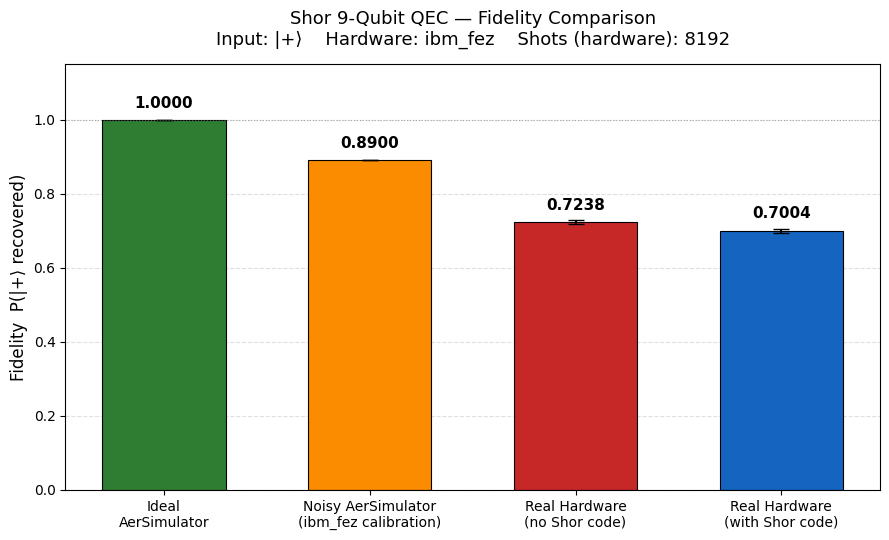

In [15]:
# Phase 5 summary plot — fidelity comparison on |+⟩

labels = [
    'Ideal\nAerSimulator',
    'Noisy AerSimulator\n(ibm_fez calibration)',
    'Real Hardware\n(no Shor code)',
    'Real Hardware\n(with Shor code)',
]
fidelities = [fidelity, avg_fidelity_noisy_simulator, p0_A, p0_B]
colors = ['#2E7D32', '#FB8C00', '#C62828', '#1565C0']

# 1σ error bars only on hardware bars (binomial: sqrt(p(1-p)/N))
err = [
    0,
    0,
    np.sqrt(p0_A * (1 - p0_A) / shots),
    np.sqrt(p0_B * (1 - p0_B) / shots),
]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(labels, fidelities, color=colors, width=0.6,
              yerr=err, capsize=6, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, fidelities):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.025,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Fidelity  P(|+⟩ recovered)', fontsize=12)
ax.set_title('Shor 9-Qubit QEC — Fidelity Comparison\nInput: |+⟩    Hardware: ibm_fez    Shots (hardware): {}'.format(shots),
             fontsize=13, pad=14)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
